# Observations

Compare toutes les méthodes du benchmark (Persistance P, Persistance P°, BLEND, AR-OLS, ELM OLS, ELM Ridge) à la vérité terrain sur 3 jours par saison, pour les 5 horizons rapportés dans `results_code.tex` (0,5 h / 1 h / 3 h / 6 h / 10 h).

- Sections 3 : toutes les méthodes sur une même grille 4 saisons × 5 horizons.
- Section 4 : Ridge vs OLS directement sur le même graphique avec la ground truth.
- Données : fichiers `results/Predictions_*.csv` (générés par `scripts/run_full.py`).
- Hypothèse : prédictions en MODE COMPLET (`Ndata = round(2 * 365.25 * 48) = 35064`, `LB_list=[48]`, `FH_list=[1,2,6,12,20]`, `ratio=0.5`).

In [1]:
from math import floor
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ROOT       = Path.cwd()
RESULTS    = ROOT / 'results'
FIG_DIR    = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

# Doit correspondre au MODE COMPLET des scripts dr_elm_*.py
DATA_START = pd.Timestamp('2020-08-01 00:00:00')
STEP       = pd.Timedelta(minutes=30)
Ndata      = round(2 * 365.25 * 48)
LB         = 48
RATIO      = 0.5

METHODS_TO_PLOT = ['BLEND_est', 'AR_OLS', 'ELM']
FH_TO_PLOT      = [1, 2, 6, 12, 20]     # 30 min / 1 h / 3 h / 6 h / 10 h (horizons du .tex)
DAYS_PER_SEASON = 3

# Fichiers par variante ELM — AR-OLS et BLEND sont chargés séparément et fusionnés
PRED_FILES = {
    'OLS'  : RESULTS / 'Predictions_DR_ELM_NICE_sklearn_simple.csv',
    'Ridge': RESULTS / 'Predictions_DR_ELM_NICE_ridge_simple.csv',
}
PRED_AR_OLS      = RESULTS / 'Predictions_AR_OLS.csv'
PRED_BLEND_OPTI  = RESULTS / 'Predictions_BLEND_optimisation.csv'
PRED_BLEND_CORRE = RESULTS / 'Predictions_BLEND_correlation.csv'

SEASONS = {
    'Hiver'    : (12,  1,  2),
    'Printemps': ( 3,  4,  5),
    'Ete'      : ( 6,  7,  8),
    'Automne'  : ( 9, 10, 11),
}

## 1. Reconstruction des timestamps

Le CSV de prédictions stocke `t_index` (0..n_test-1) sans date. On reconstitue le timestamp cible à partir de la configuration du script :

```
n_windows = Ndata - LB - FH + 1
idx_split = floor(RATIO * n_windows)
offset    = idx_split + LB + FH - 1            # indice dans le tableau resamplé
ts(k)     = DATA_START + (offset + k) * 30min  # avec k = t_index
```

In [2]:
def add_timestamps(df: pd.DataFrame) -> pd.DataFrame:
    """Ajoute la colonne `ts` (timestamp de la cible y_true) au DataFrame."""
    out = []
    for (lb_days, fh_hours), g in df.groupby(['LB_days', 'FH_hours']):
        lb = int(round(lb_days * 48))
        fh = int(round(fh_hours / 0.5))
        n_windows = Ndata - lb - fh + 1
        idx_split = floor(RATIO * n_windows)
        offset    = idx_split + lb + fh - 1
        g = g.copy()
        g['ts'] = DATA_START + (offset + g['t_index'].to_numpy()) * STEP
        out.append(g)
    return pd.concat(out, ignore_index=True)

# Un dict par source : nom --> DataFrame avec colonne Method renommée si besoin
preds = {}

for name, path in PRED_FILES.items():
    if not path.exists():
        print(f'[skip] {name}: {path} introuvable')
        continue
    df = pd.read_csv(path)
    df['Method'] = df['Method'].replace('ELM_full', 'ELM')
    df = df[df['Method'] == 'ELM'].copy()
    df = add_timestamps(df)
    preds[name] = df
    print(f'{name}: {len(df):,} lignes  méthodes={sorted(df.Method.unique())}')

# AR-OLS + les deux variantes de BLEND (optimisation et corrélation)
EXTRA_SOURCES = [
    ('AR-OLS',     PRED_AR_OLS,      'AR_OLS'),
    ('BLEND_opti', PRED_BLEND_OPTI,  'BLEND_est'),
    ('BLEND_corre', PRED_BLEND_CORRE, 'BLEND_est'),
]
for name, path, method_col in EXTRA_SOURCES:
    if not path.exists():
        print(f'[skip] {name}: {path} introuvable')
        continue
    df = pd.read_csv(path)
    df = df[df['Method'] == method_col].copy()
    df = add_timestamps(df)
    preds[name] = df
    print(f'{name}: {len(df):,} lignes  méthodes={sorted(df.Method.unique())}')

OLS: 87,524 lignes  méthodes=['ELM']
Ridge: 87,524 lignes  méthodes=['ELM']
AR-OLS: 87,524 lignes  méthodes=['AR_OLS']
BLEND_opti: 87,524 lignes  méthodes=['BLEND_est']
BLEND_corre: 87,524 lignes  méthodes=['BLEND_est']


## 2. Sélection de 3 jours par saison

On cherche, dans la période de test, **un bloc contigu de 3 jours** dans chaque saison météo. Pour la reproductibilité on prend le premier bloc disponible — modifier `pick_window` si on veut un autre critère (jour le plus ensoleillé, etc.).

In [3]:
def pick_window(ts_series: pd.Series, months: tuple, n_days: int = DAYS_PER_SEASON):
    """Premier bloc contigu de `n_days` jours dont tous les jours sont dans `months`."""
    days = pd.Series(ts_series.dt.normalize().unique()).sort_values().reset_index(drop=True)
    days_in = days[days.dt.month.isin(months)].reset_index(drop=True)
    if len(days_in) < n_days:
        return None
    for i in range(len(days_in) - n_days + 1):
        window = days_in.iloc[i:i + n_days]
        if (window.iloc[-1] - window.iloc[0]).days == n_days - 1:
            start = window.iloc[0]
            end   = start + pd.Timedelta(days=n_days)
            return start, end
    return None

# Sanity check sur le premier dataset disponible
if preds:
    sample = next(iter(preds.values()))
    for season, months in SEASONS.items():
        w = pick_window(sample['ts'], months)
        print(f'{season:10s}: {w}')


Hiver     : (Timestamp('2021-12-01 00:00:00'), Timestamp('2021-12-04 00:00:00'))
Printemps : (Timestamp('2022-03-01 00:00:00'), Timestamp('2022-03-04 00:00:00'))
Ete       : (Timestamp('2021-08-01 00:00:00'), Timestamp('2021-08-04 00:00:00'))
Automne   : (Timestamp('2021-09-01 00:00:00'), Timestamp('2021-09-04 00:00:00'))


## 3. Tracé — une figure par modèle vs ground truth

Grille **4 saisons × 5 horizons** pour chacun des quatre modèles : ELM OLS, ELM Ridge, AR-OLS, BLEND.

Sauvegardé : /home/martin/M1/Stage/python_prediction/figures/pred_vs_truth_ols.png


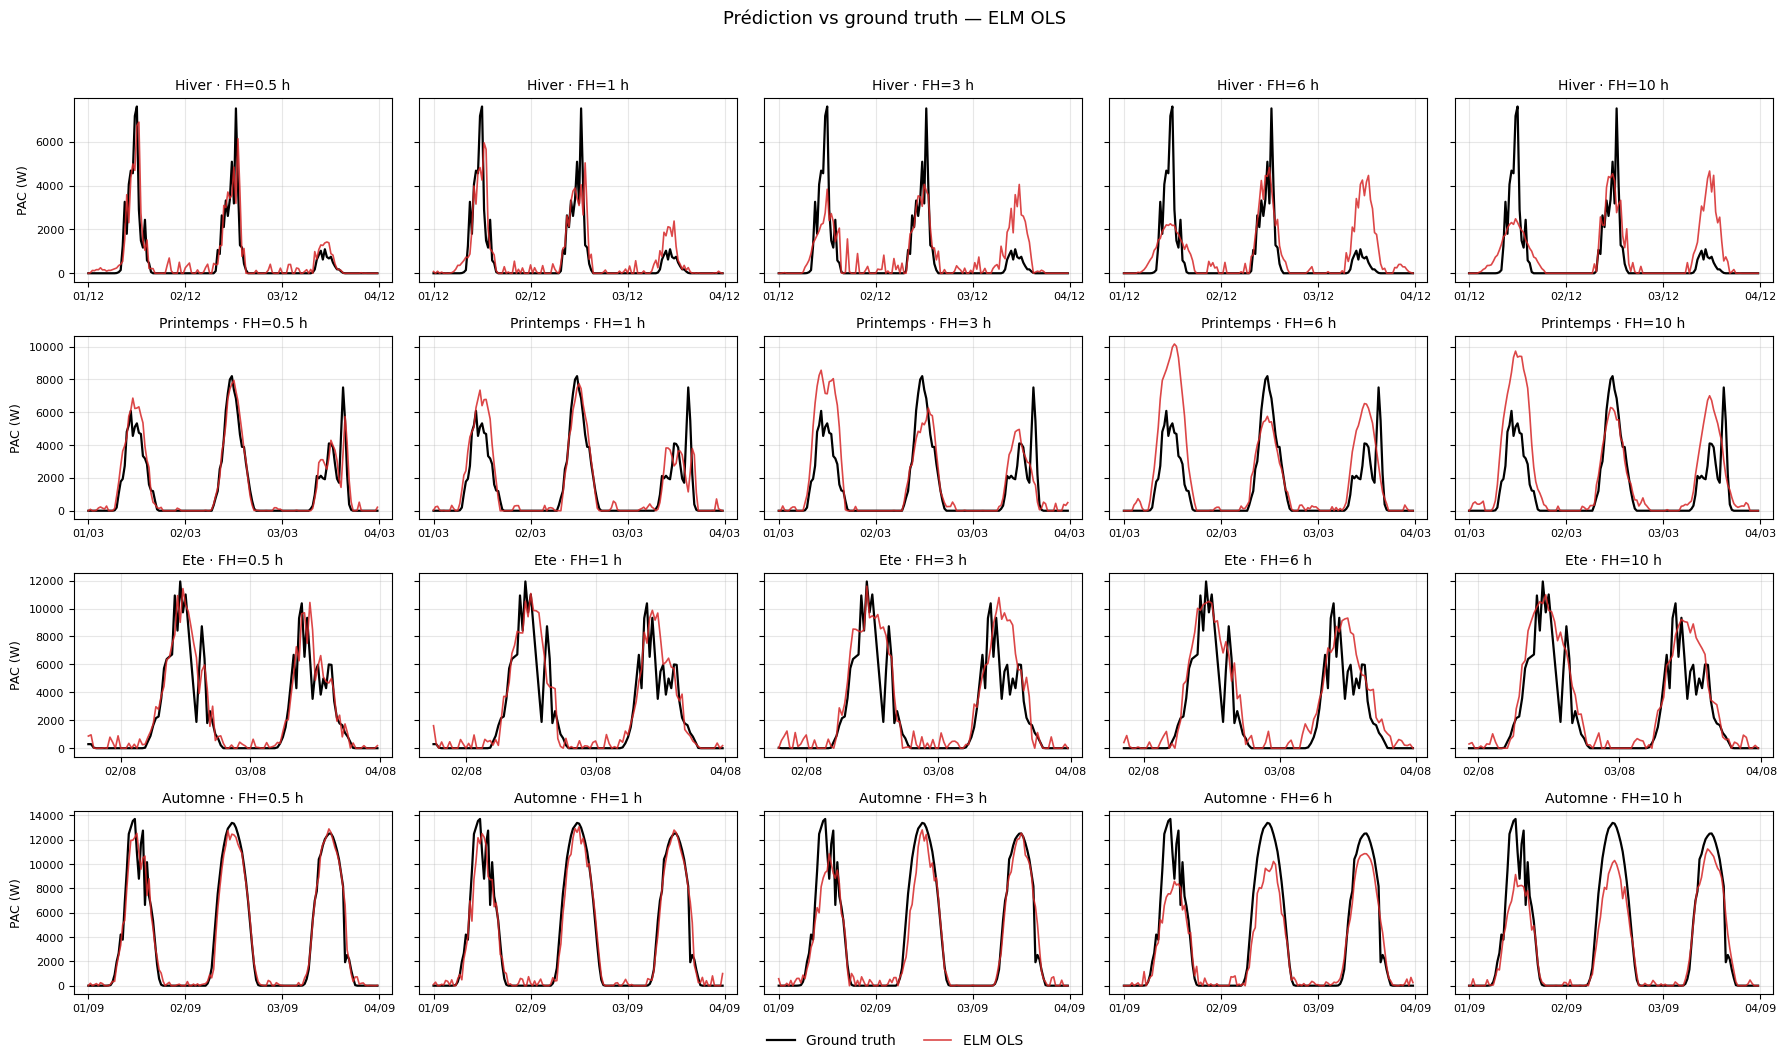

Sauvegardé : /home/martin/M1/Stage/python_prediction/figures/pred_vs_truth_ridge.png


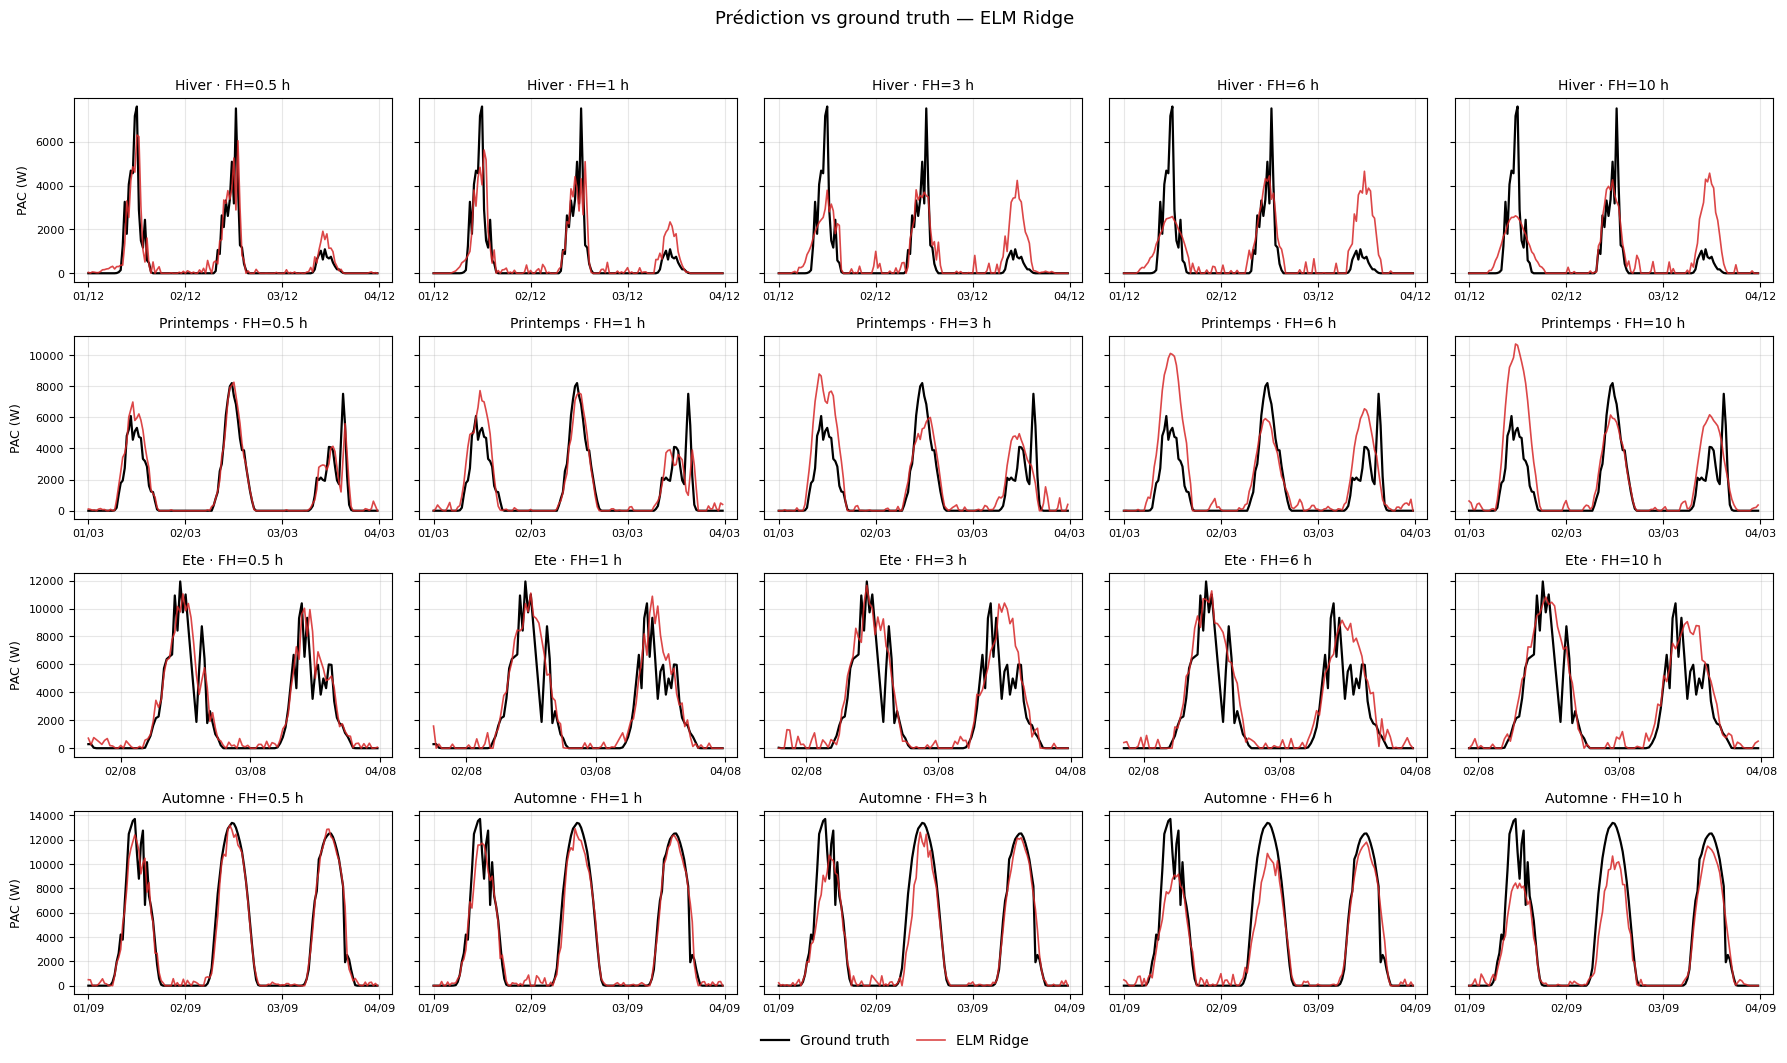

Sauvegardé : /home/martin/M1/Stage/python_prediction/figures/pred_vs_truth_ar_ols.png


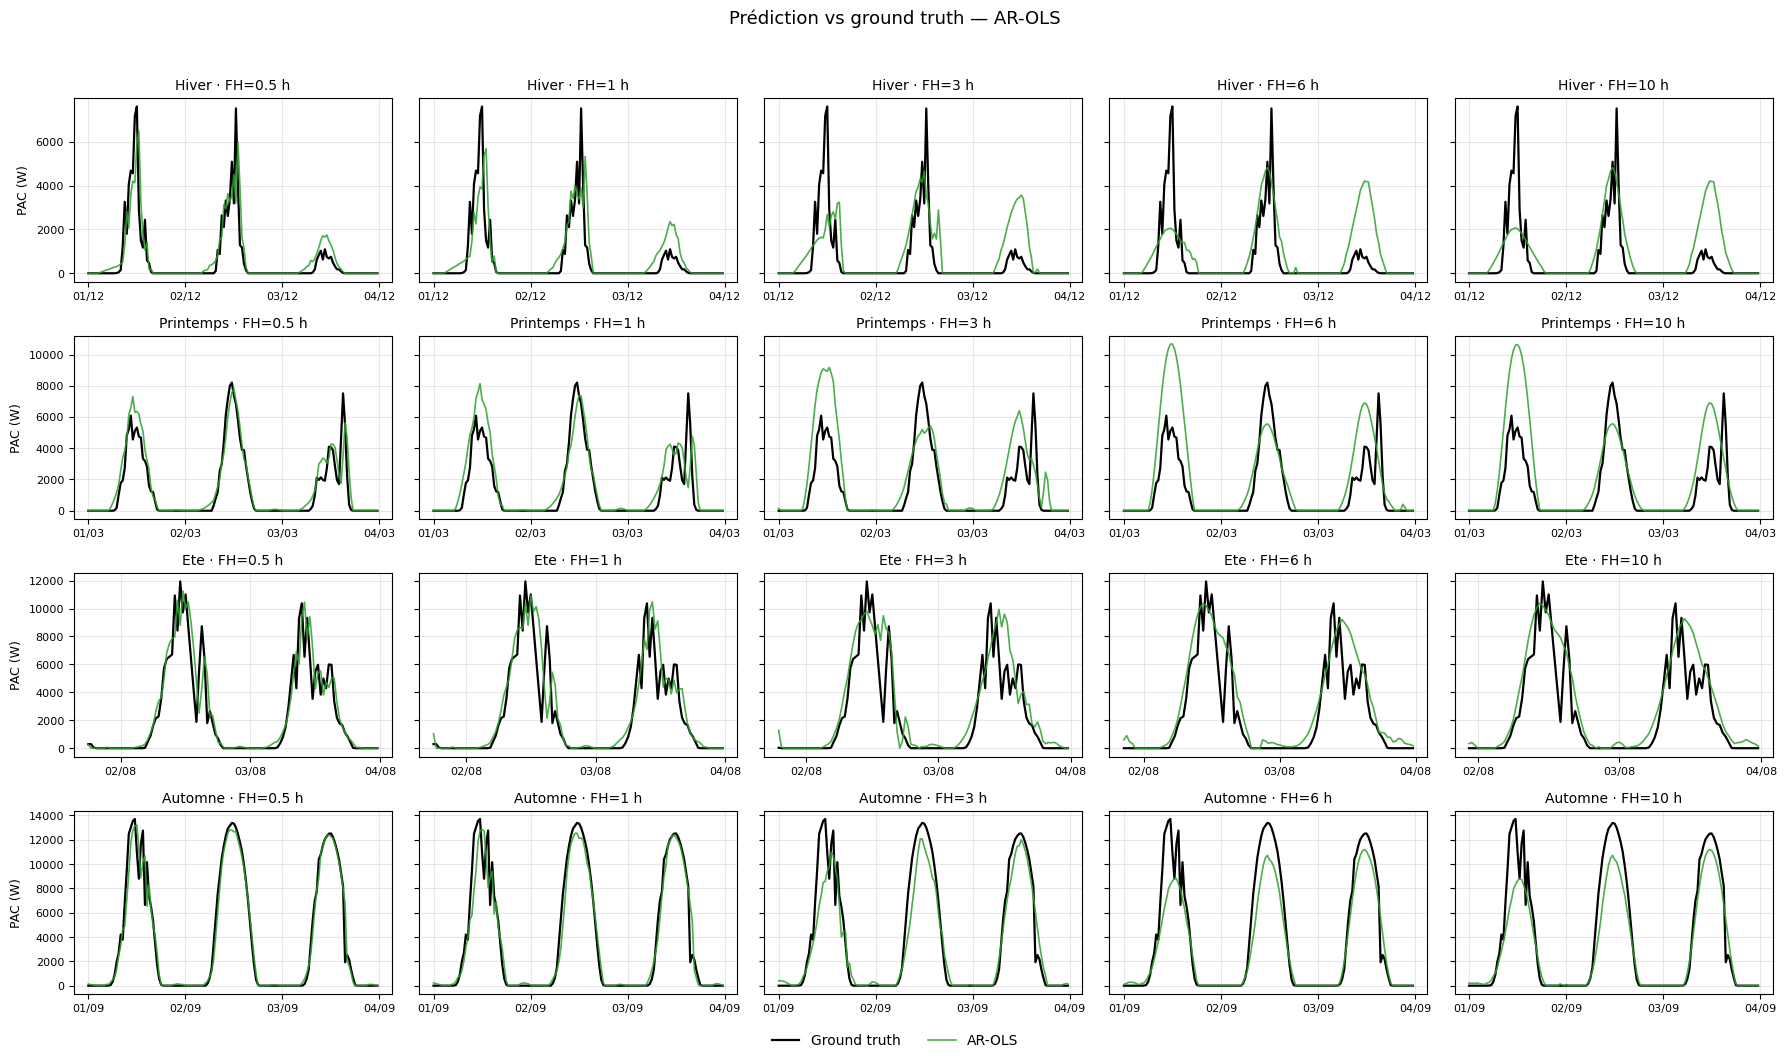

Sauvegardé : /home/martin/M1/Stage/python_prediction/figures/pred_vs_truth_blend_opti.png


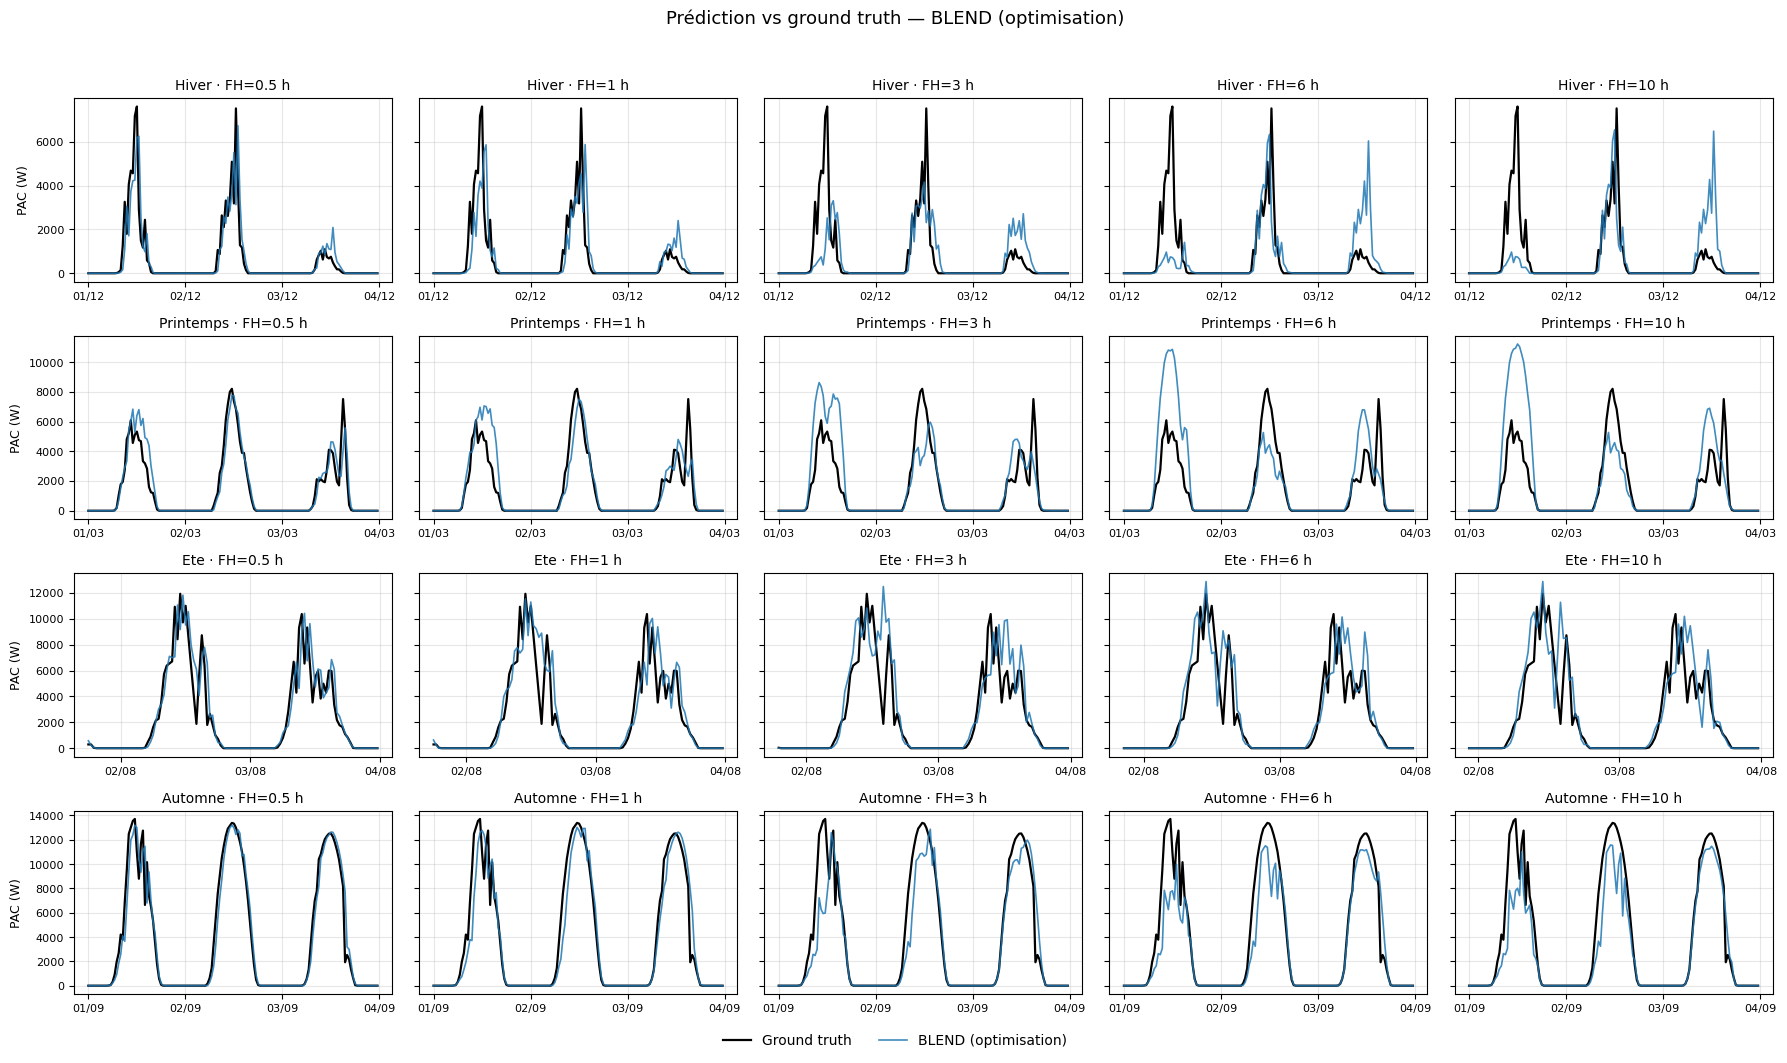

Sauvegardé : /home/martin/M1/Stage/python_prediction/figures/pred_vs_truth_blend_corre.png


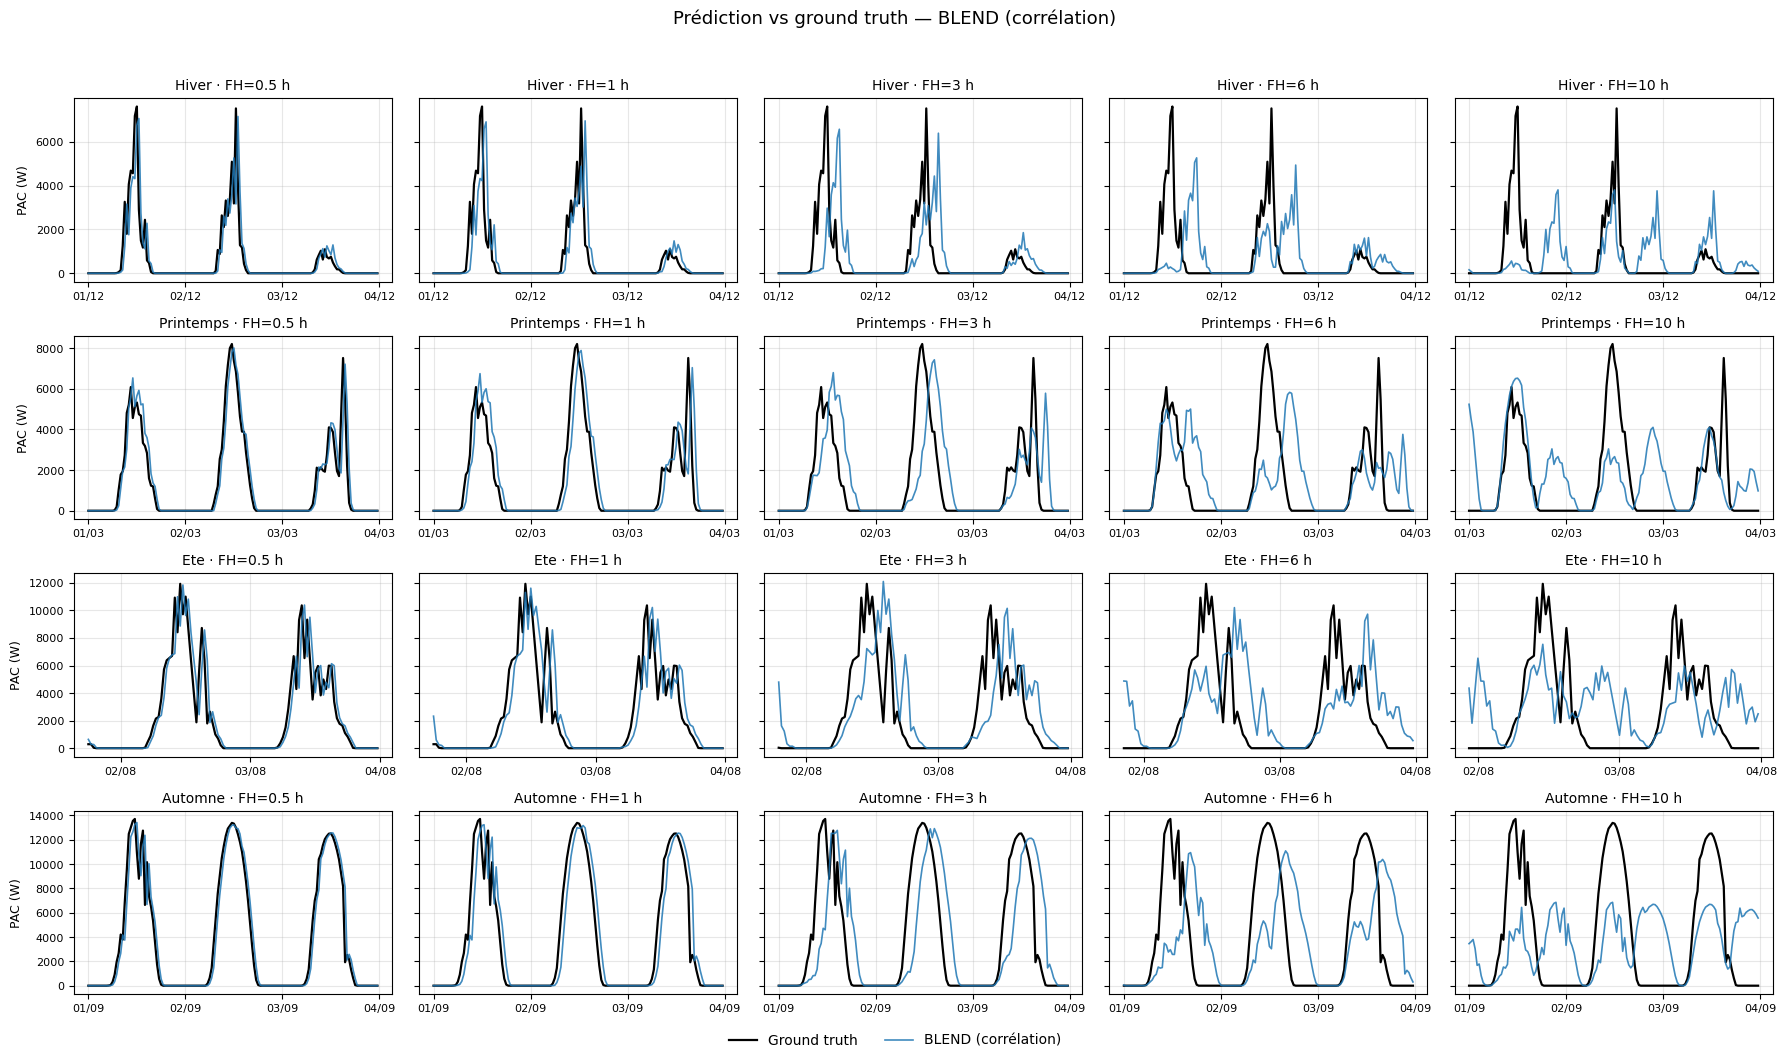

In [12]:
METHOD_STYLES = {
    'ELM'      : dict(color='#d62728', linewidth=1.2, alpha=0.85),
    'AR_OLS'   : dict(color='#2ca02c', linewidth=1.2, alpha=0.85),
    'BLEND_est': dict(color='#1f77b4', linewidth=1.2, alpha=0.85),
}
GT_STYLE = dict(color='black', linewidth=1.6, label='Ground truth')

DISPLAY_NAMES = {
    'OLS'        : 'ELM OLS',
    'Ridge'      : 'ELM Ridge',
    'AR-OLS'     : 'AR-OLS',
    'BLEND_opti' : 'BLEND (optimisation)',
    'BLEND_corre': 'BLEND (corrélation)',
}

def plot_single(df: pd.DataFrame, variant_name: str):
    """Une figure 4 saisons × 5 horizons pour un seul modèle vs ground truth."""
    method_col = df['Method'].iloc[0]
    style = METHOD_STYLES.get(method_col, dict(color='#9467bd', linewidth=1.2, alpha=0.85))
    label = DISPLAY_NAMES.get(variant_name, variant_name)

    n_rows, n_cols = len(SEASONS), len(FH_TO_PLOT)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(3.6 * n_cols, 2.6 * n_rows),
                             sharey='row', squeeze=False)

    for r, (season, months) in enumerate(SEASONS.items()):
        win = pick_window(df['ts'], months)
        for c, fh in enumerate(FH_TO_PLOT):
            ax = axes[r, c]
            fh_hours = fh * 0.5
            sub = df[df['FH_hours'] == fh_hours]
            if win is None or sub.empty:
                ax.set_axis_off()
                ax.text(0.5, 0.5, 'pas de données', ha='center', va='center',
                        transform=ax.transAxes, fontsize=9, color='gray')
                continue
            start, end = win
            sub = sub[(sub['ts'] >= start) & (sub['ts'] < end)].sort_values('ts')

            ax.plot(sub['ts'], sub['y_true'], **GT_STYLE)
            ax.plot(sub['ts'], sub['y_pred'], label=label, **style)

            ax.set_title(f'{season} · FH={fh_hours:g} h', fontsize=10)
            ax.xaxis.set_major_locator(mdates.DayLocator())
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
            ax.tick_params(axis='x', rotation=0, labelsize=8)
            ax.tick_params(axis='y', labelsize=8)
            ax.grid(True, alpha=0.3)
            if c == 0:
                ax.set_ylabel('PAC (W)', fontsize=9)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(labels),
               bbox_to_anchor=(0.5, -0.01), frameon=False, fontsize=10)
    fig.suptitle(f'Prédiction vs ground truth — {label}', fontsize=13, y=1.00)
    fig.tight_layout(rect=[0, 0.02, 1, 0.98])

    fname = variant_name.lower().replace('-', '_').replace(' ', '_')
    out = FIG_DIR / f'pred_vs_truth_{fname}.png'
    fig.savefig(out, dpi=130, bbox_inches='tight')
    print(f'Sauvegardé : {out}')
    plt.show()

for name, df in preds.items():
    plot_single(df, name)

## 4. Ridge vs OLS — comparaison directe avec la ground truth

Même grille **4 saisons × 5 horizons**, mais les deux courbes sont `ELM_OLS` et `ELM_Ridge` (plus la ground truth).
Permet de voir directement si la régularisation Ridge change la forme de la prédiction.

Sauvegardé : /home/martin/M1/Stage/python_prediction/figures/pred_vs_truth_ridge_vs_ols.png


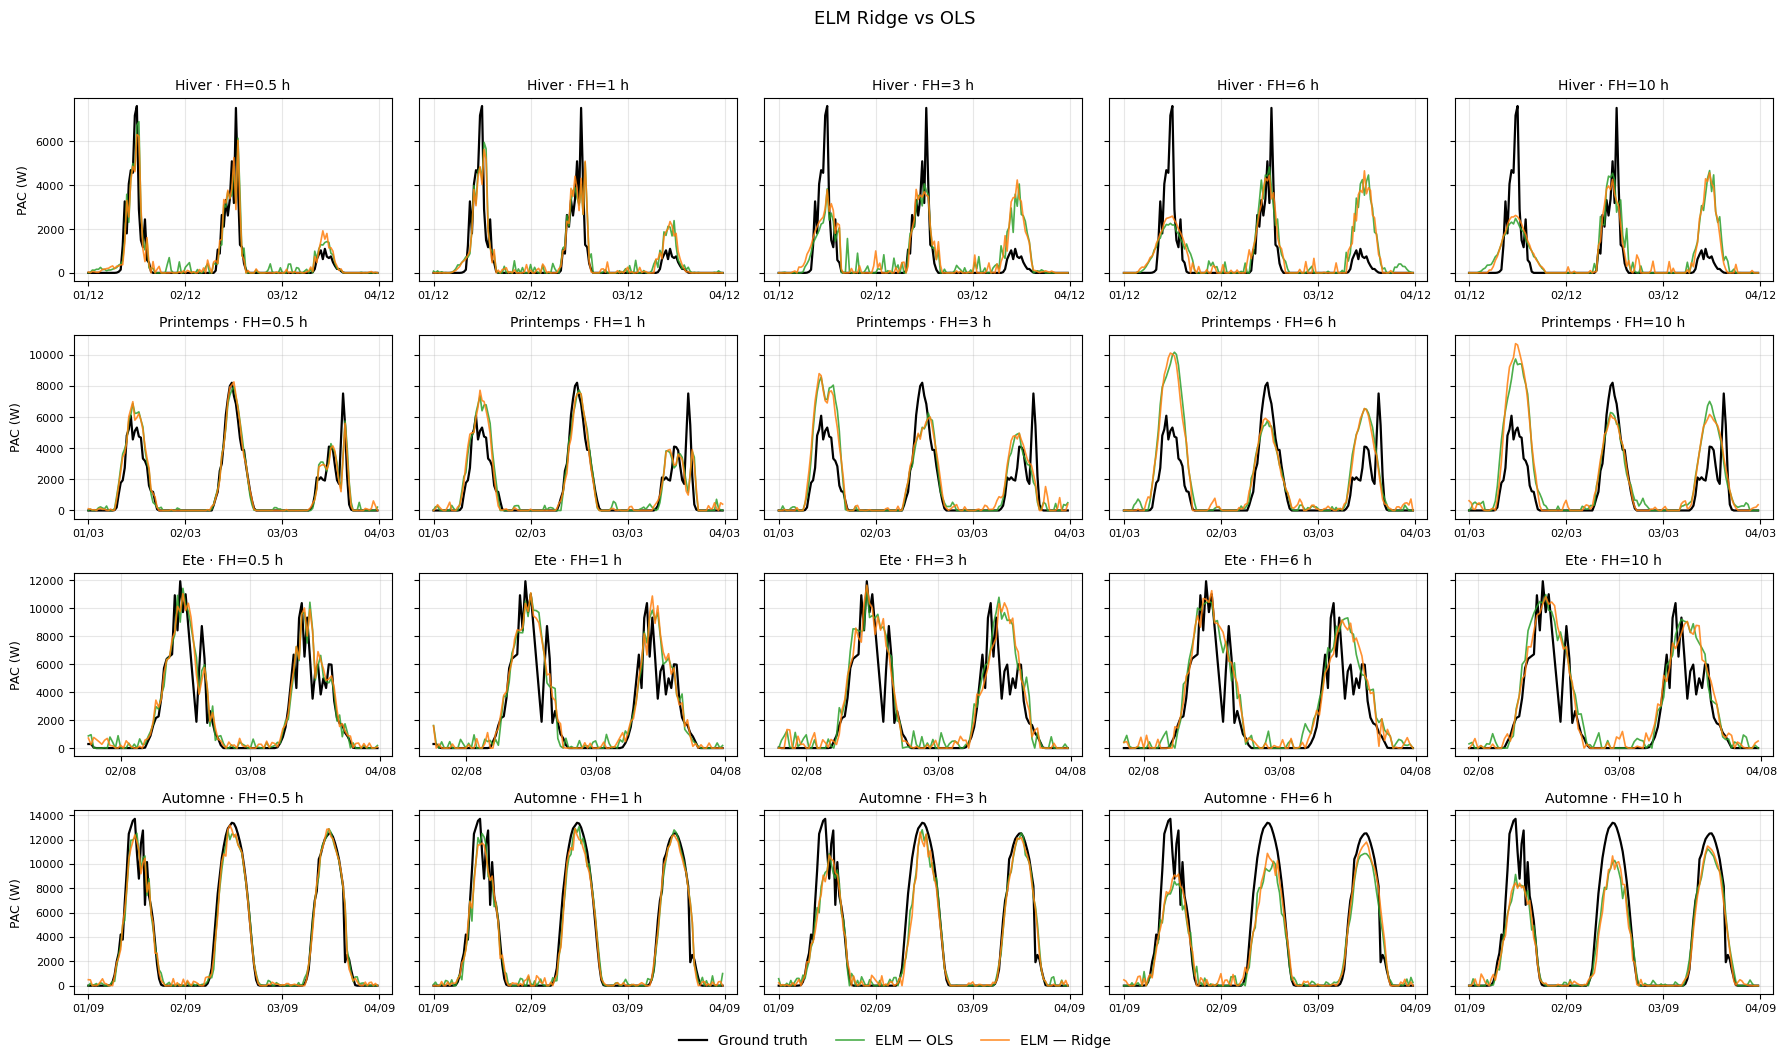

In [5]:
STYLES_COMPARE = {
    'y_true'   : dict(color='black',   linewidth=1.6, label='Ground truth'),
    'ELM_OLS'  : dict(color='#2ca02c', linewidth=1.2, alpha=0.85, label='ELM — OLS'),
    'ELM_Ridge': dict(color='#ff7f0e', linewidth=1.2, alpha=0.85, label='ELM — Ridge'),
}

if len(preds) < 2:
    print('[skip] Il faut les deux fichiers (OLS et Ridge) pour cette section.')
else:
    df_ols   = preds['OLS'][preds['OLS']['Method'] == 'ELM'].copy()
    df_ridge = preds['Ridge'][preds['Ridge']['Method'] == 'ELM'].copy()

    n_rows, n_cols = len(SEASONS), len(FH_TO_PLOT)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(3.6 * n_cols, 2.6 * n_rows),
                             sharey='row', squeeze=False)

    for r, (season, months) in enumerate(SEASONS.items()):
        win = pick_window(df_ols['ts'], months)
        for c, fh in enumerate(FH_TO_PLOT):
            ax = axes[r, c]
            fh_hours = fh * 0.5

            sub_ols   = df_ols[df_ols['FH_hours'] == fh_hours]
            sub_ridge = df_ridge[df_ridge['FH_hours'] == fh_hours]

            if win is None or sub_ols.empty:
                ax.set_axis_off()
                continue
            start, end = win
            sub_ols   = sub_ols[(sub_ols['ts'] >= start)   & (sub_ols['ts'] < end)].sort_values('ts')
            sub_ridge = sub_ridge[(sub_ridge['ts'] >= start) & (sub_ridge['ts'] < end)].sort_values('ts')

            ax.plot(sub_ols['ts'],   sub_ols['y_true'],  **STYLES_COMPARE['y_true'])
            ax.plot(sub_ols['ts'],   sub_ols['y_pred'],  **STYLES_COMPARE['ELM_OLS'])
            ax.plot(sub_ridge['ts'], sub_ridge['y_pred'], **STYLES_COMPARE['ELM_Ridge'])

            ax.set_title(f'{season} · FH={fh_hours:g} h', fontsize=10)
            ax.xaxis.set_major_locator(mdates.DayLocator())
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
            ax.tick_params(axis='x', rotation=0, labelsize=8)
            ax.tick_params(axis='y', labelsize=8)
            ax.grid(True, alpha=0.3)
            if c == 0:
                ax.set_ylabel('PAC (W)', fontsize=9)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(labels),
               bbox_to_anchor=(0.5, -0.01), frameon=False, fontsize=10)
    fig.suptitle('ELM Ridge vs OLS', fontsize=13, y=1.00)
    fig.tight_layout(rect=[0, 0.02, 1, 0.98])

    out = FIG_DIR / 'pred_vs_truth_ridge_vs_ols.png'
    fig.savefig(out, dpi=130, bbox_inches='tight')
    print(f'Sauvegardé : {out}')
    plt.show()

## 5. Slide de présentation — journée claire vs journée nuageuse

Pour la présentation orale : deux journées choisies automatiquement dans la période de test, à **FH = 1 h**, avec les trois modèles (BLEND, AR-OLS, ELM) superposés à la vérité terrain.

- **Journée claire** : journée d'été dont la courbe de PAC est la plus proche d'une cloche lisse (faible bruit relatif autour d'un lissage gaussien).
- **Journée nuageuse** : journée dont la courbe de PAC en plein jour présente le plus de variations rapides (forte rugosité relative).

Les figures sont sauvegardées dans `figures/` pour pouvoir être insérées telles quelles dans la slide.

In [6]:
FH_SLIDE = 1  # FH=1 => 0.5 h ; on veut 1 h => FH index = 2
FH_SLIDE_HOURS = 1.0

# Construit un DataFrame "long" avec une colonne par modèle pour FH=1h
def build_long_fh(fh_hours: float) -> pd.DataFrame:
    """Rassemble y_true + une colonne y_pred par modèle, indexées par ts, pour un FH donné."""
    parts = {}
    for key, df in preds.items():
        sub = df[df['FH_hours'] == fh_hours].copy()
        if sub.empty:
            continue
        sub = sub.set_index('ts')[['y_true', 'y_pred']]
        parts[key] = sub
    if not parts:
        return pd.DataFrame()
    # On prend y_true du premier (tous identiques au même ts)
    ref_key = next(iter(parts))
    out = parts[ref_key][['y_true']].copy()
    for key, sub in parts.items():
        out[key] = sub['y_pred']
    return out.dropna().sort_index()

long_fh = build_long_fh(FH_SLIDE_HOURS)
print(f'FH={FH_SLIDE_HOURS} h  -> {len(long_fh):,} pas, colonnes={list(long_fh.columns)}')
print(f'Période test : {long_fh.index.min()}  ->  {long_fh.index.max()}')

FH=1.0 h  -> 17,508 pas, colonnes=['y_true', 'OLS', 'Ridge', 'AR-OLS', 'BLEND_opti', 'BLEND_corre']
Période test : 2021-08-01 18:00:00  ->  2022-08-01 11:30:00


In [7]:
# Sélection automatique des deux journées
# - claire   : pic max ET faible rugosité (variations rapides)
# - nuageuse : pic >= 30% du max climatologique ET forte rugosité

def daily_features(s_day: pd.Series) -> dict:
    """Renvoie pic, énergie, et 'rugosité' = écart-type des diffs absolues normalisée par le pic."""
    if s_day.empty:
        return dict(peak=0.0, energy=0.0, rough=0.0)
    peak = float(s_day.max())
    energy = float(s_day.sum())
    if peak < 1.0:
        return dict(peak=peak, energy=energy, rough=0.0)
    # Rugosité : moyenne des |Δ| en plein jour (PAC > 10% du pic), normalisée
    daylight = s_day[s_day > 0.1 * peak]
    if len(daylight) < 4:
        return dict(peak=peak, energy=energy, rough=0.0)
    diffs = np.abs(np.diff(daylight.to_numpy()))
    rough = float(diffs.mean() / peak)
    return dict(peak=peak, energy=energy, rough=rough)

# Grouper la vérité terrain par jour calendaire
gt = long_fh['y_true']
by_day = gt.groupby(gt.index.normalize())

stats = []
for day, s in by_day:
    if len(s) < 40:  # journée incomplète
        continue
    feat = daily_features(s)
    feat['day'] = day
    stats.append(feat)

df_days = pd.DataFrame(stats).set_index('day')
peak_max = df_days['peak'].quantile(0.95)  # référence "ensoleillé"

# Journée claire : pic élevé + rugosité faible
mask_clear = df_days['peak'] >= 0.85 * peak_max
clear_day = df_days.loc[mask_clear, 'rough'].idxmin()

# Journée nuageuse : pic correct (sinon c'est juste une journée d'hiver) + rugosité élevée
mask_cloud = df_days['peak'] >= 0.30 * peak_max
cloud_day = df_days.loc[mask_cloud, 'rough'].idxmax()

print(f"Journée claire   : {clear_day.date()}  "
      f"(pic={df_days.loc[clear_day,'peak']:.0f} W, rugosité={df_days.loc[clear_day,'rough']:.3f})")
print(f"Journée nuageuse : {cloud_day.date()}  "
      f"(pic={df_days.loc[cloud_day,'peak']:.0f} W, rugosité={df_days.loc[cloud_day,'rough']:.3f})")

Journée claire   : 2022-06-16  (pic=13530 W, rugosité=0.071)
Journée nuageuse : 2021-11-10  (pic=5101 W, rugosité=0.390)


Sauvegardé : /home/martin/M1/Stage/python_prediction/figures/slide_journee_claire.png


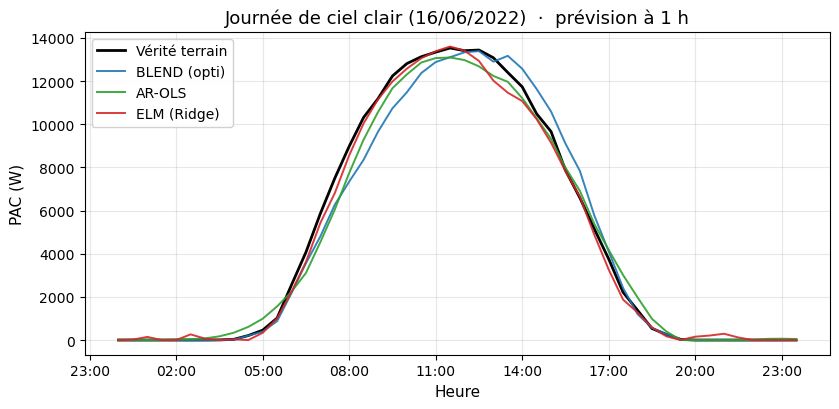

Sauvegardé : /home/martin/M1/Stage/python_prediction/figures/slide_journee_nuageuse.png


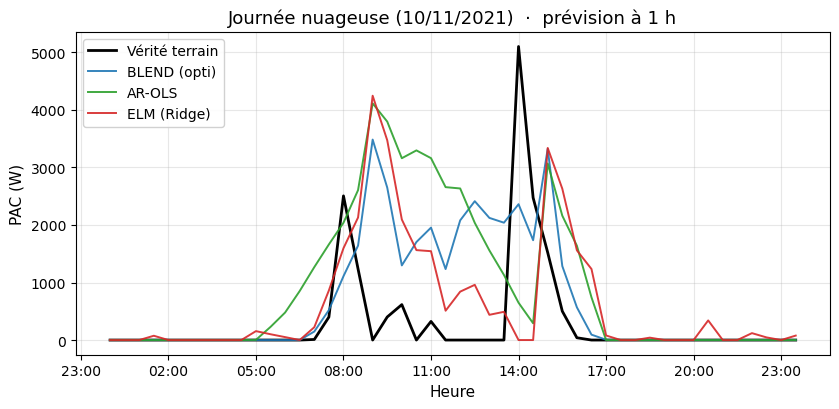

In [8]:
# Tracé : une figure par journée, 3 modèles + vérité terrain, FH=1h
SLIDE_STYLES = {
    'y_true'     : dict(color='black',   linewidth=2.0, label='Vérité terrain'),
    'BLEND_opti' : dict(color='#1f77b4', linewidth=1.4, alpha=0.9, label='BLEND (opti)'),
    'AR-OLS'     : dict(color='#2ca02c', linewidth=1.4, alpha=0.9, label='AR-OLS'),
    'Ridge'      : dict(color='#d62728', linewidth=1.4, alpha=0.9, label='ELM (Ridge)'),
}
MODEL_ORDER = ['BLEND_opti', 'AR-OLS', 'Ridge']

def plot_day(day: pd.Timestamp, titre: str, fname: str) -> None:
    start = day
    end = day + pd.Timedelta(days=1)
    sub = long_fh[(long_fh.index >= start) & (long_fh.index < end)]
    if sub.empty:
        print(f"[skip] aucune donnée pour {day.date()}")
        return

    fig, ax = plt.subplots(figsize=(8.5, 4.2))
    ax.plot(sub.index, sub['y_true'], **SLIDE_STYLES['y_true'])
    for m in MODEL_ORDER:
        if m in sub.columns:
            ax.plot(sub.index, sub[m], **SLIDE_STYLES[m])

    ax.set_title(f'{titre} ({day.strftime("%d/%m/%Y")})  ·  prévision à 1 h',
                 fontsize=13)
    ax.set_ylabel('PAC (W)', fontsize=11)
    ax.set_xlabel('Heure', fontsize=11)
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
    fig.tight_layout()

    out = FIG_DIR / fname
    fig.savefig(out, dpi=140, bbox_inches='tight')
    print(f'Sauvegardé : {out}')
    plt.show()

plot_day(clear_day, 'Journée de ciel clair',  'slide_journee_claire.png')
plot_day(cloud_day, 'Journée nuageuse',       'slide_journee_nuageuse.png')

### 5.1 Slide 2 — Aperçu des données (1 semaine de PAC)

Une semaine typique pour montrer le cycle jour/nuit, la variabilité jour-à-jour, et l'ordre de grandeur (~13 kW pic).

Sauvegardé : /home/martin/M1/Stage/python_prediction/figures/slide_donnees_semaine.png


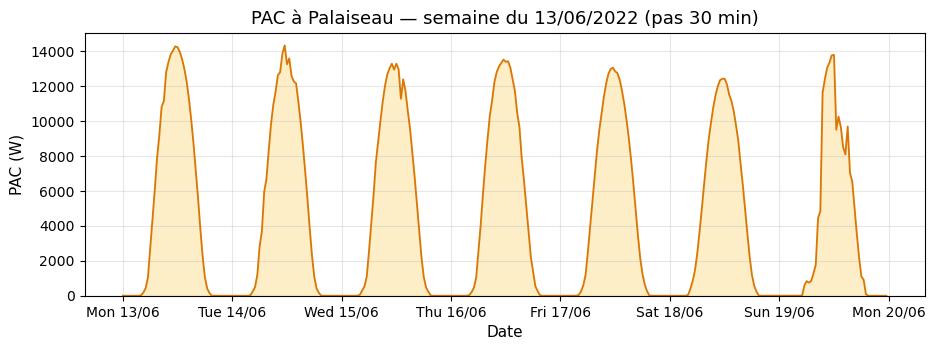

In [9]:
DATA_NPY = ROOT / 'data' / 'data_30min.npy'
data_full = np.load(DATA_NPY)
ts_full = DATA_START + np.arange(len(data_full)) * STEP

# Une semaine d'été pour la slide (juin 2022)
WEEK_START = pd.Timestamp('2022-06-13')
WEEK_END = WEEK_START + pd.Timedelta(days=7)
mask = (ts_full >= WEEK_START) & (ts_full < WEEK_END)

fig, ax = plt.subplots(figsize=(9.5, 3.6))
ax.plot(ts_full[mask], data_full[mask], color='#d97706', linewidth=1.3)
ax.fill_between(ts_full[mask], 0, data_full[mask], color='#fbbf24', alpha=0.25)
ax.set_title(f'PAC à Palaiseau — semaine du {WEEK_START.strftime("%d/%m/%Y")} (pas 30 min)',
             fontsize=13)
ax.set_ylabel('PAC (W)', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %d/%m'))
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
fig.tight_layout()
out = FIG_DIR / 'slide_donnees_semaine.png'
fig.savefig(out, dpi=140, bbox_inches='tight')
print(f'Sauvegardé : {out}')
plt.show()

### 5.2 Slide 2/3 — Découpage train / test

Frise temporelle des 2 ans utilisés, séparée en 50 % train / 50 % test chronologique.

Sauvegardé : /home/martin/M1/Stage/python_prediction/figures/slide_train_test.png


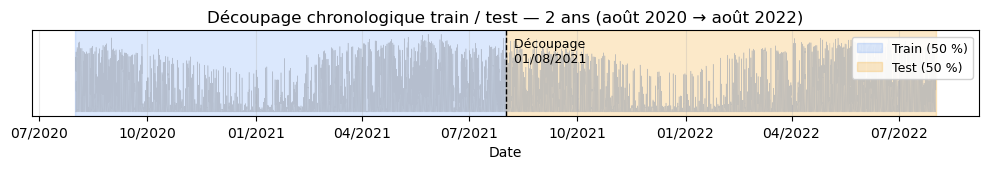

In [10]:
data_used = data_full[:Ndata]
ts_used = DATA_START + np.arange(Ndata) * STEP
split_idx = floor(0.5 * Ndata)
ts_split = ts_used[split_idx]
ts_split_pd = pd.Timestamp(ts_split)

fig, ax = plt.subplots(figsize=(10, 1.8))
ax.plot(ts_used, data_used, color='#9ca3af', linewidth=0.4, alpha=0.6)
ax.axvspan(ts_used[0], ts_split, color='#3b82f6', alpha=0.18, label='Train (50 %)')
ax.axvspan(ts_split, ts_used[-1], color='#f59e0b', alpha=0.22, label='Test (50 %)')
ax.axvline(ts_split, color='black', linewidth=1.0, linestyle='--')
ax.text(ts_split_pd, ax.get_ylim()[1] * 0.92, f'  Découpage\n  {ts_split_pd.strftime("%d/%m/%Y")}',
        fontsize=9, va='top')
ax.set_title('Découpage chronologique train / test — 2 ans (août 2020 → août 2022)',
             fontsize=12)
ax.set_xlabel('Date', fontsize=10)
ax.set_yticks([])
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.grid(True, axis='x', alpha=0.3)
fig.tight_layout()
out = FIG_DIR / 'slide_train_test.png'
fig.savefig(out, dpi=140, bbox_inches='tight')
print(f'Sauvegardé : {out}')
plt.show()

### 5.3 Slide 4 — $NICE^\Sigma$ jour seul en fonction de l'horizon

**Le graphe central de la présentation.** Une courbe par modèle. Persistance simple = 1 par construction. Plus la courbe est basse, meilleur est le modèle.

Sauvegardé : /home/martin/M1/Stage/python_prediction/figures/slide_nice_vs_horizon.png


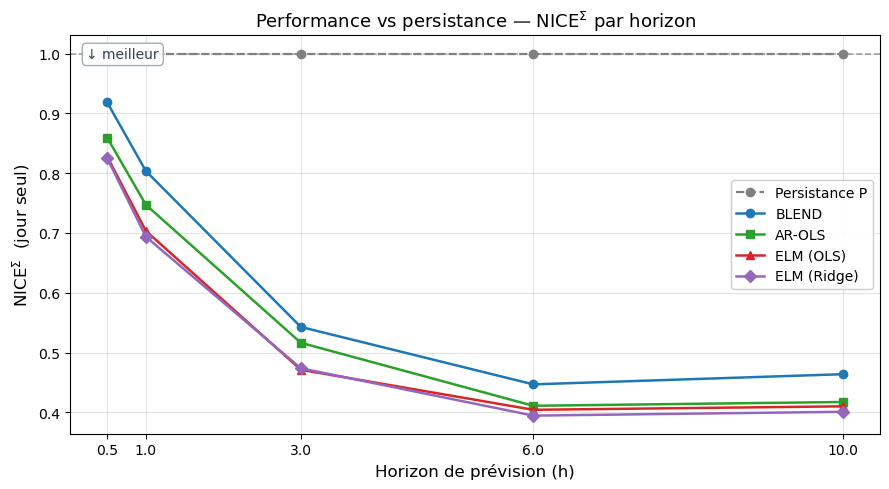


NICE_Sigma (jour seul) par horizon :
          BLEND  AR-OLS  ELM (OLS)  ELM (Ridge)
FH_hours                                       
0.5       0.919   0.859      0.828        0.825
1.0       0.804   0.747      0.703        0.694
3.0       0.543   0.516      0.471        0.474
6.0       0.447   0.411      0.404        0.394
10.0      0.464   0.417      0.410        0.401


In [11]:
RES_FILES = {
    'BLEND'      : RESULTS / 'Results_BLEND_optimisation_day.csv',
    'AR-OLS'     : RESULTS / 'Results_AR_OLS_day.csv',
    'ELM (OLS)'  : RESULTS / 'Results_DR_ELM_NICE_sklearn_simple_day.csv',
    'ELM (Ridge)': RESULTS / 'Results_DR_ELM_NICE_ridge_simple_day.csv',
}
TARGET_METHODS = {
    'BLEND'      : 'BLEND_est',
    'AR-OLS'     : 'AR_OLS',
    'ELM (OLS)'  : 'ELM',
    'ELM (Ridge)': 'ELM',
}
CURVE_STYLES = {
    'Persistance' : dict(color='gray',    linewidth=1.6, linestyle='--', marker='o', label='Persistance P'),
    'BLEND'       : dict(color='#1f77b4', linewidth=1.8, marker='o', label='BLEND'),
    'AR-OLS'      : dict(color='#2ca02c', linewidth=1.8, marker='s', label='AR-OLS'),
    'ELM (OLS)'   : dict(color='#d62728', linewidth=1.8, marker='^', label='ELM (OLS)'),
    'ELM (Ridge)' : dict(color='#9467bd', linewidth=1.8, marker='D', label='ELM (Ridge)'),
}

curves: dict[str, pd.DataFrame] = {}
for name, path in RES_FILES.items():
    df = pd.read_csv(path)
    sub = df[df['Method'] == TARGET_METHODS[name]].copy()
    sub = sub.sort_values('FH_hours')
    curves[name] = sub[['FH_hours', 'NICE_Sigma']].reset_index(drop=True)

fh_axis = curves['BLEND']['FH_hours'].to_numpy()

fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(1.0, color='gray', linewidth=1.2, linestyle='--', alpha=0.7)
ax.plot(fh_axis, np.ones_like(fh_axis), **CURVE_STYLES['Persistance'])
for name in ['BLEND', 'AR-OLS', 'ELM (OLS)', 'ELM (Ridge)']:
    c = curves[name]
    ax.plot(c['FH_hours'], c['NICE_Sigma'], **CURVE_STYLES[name])

ax.set_xlabel('Horizon de prévision (h)', fontsize=12)
ax.set_ylabel(r'NICE$^\Sigma$  (jour seul)', fontsize=12)
ax.set_title(r'Performance vs persistance — NICE$^\Sigma$ par horizon', fontsize=13)
ax.set_xticks(fh_axis)
ax.grid(True, alpha=0.35)
ax.legend(loc='center right', fontsize=10, framealpha=0.95)
ax.text(0.02, 0.97, '↓ meilleur', transform=ax.transAxes,
        fontsize=10, va='top', color='#374151',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#9ca3af', alpha=0.9))
fig.tight_layout()
out = FIG_DIR / 'slide_nice_vs_horizon.png'
fig.savefig(out, dpi=140, bbox_inches='tight')
print(f'Sauvegardé : {out}')
plt.show()

# Récap tabulaire pour le rapport oral
recap = pd.DataFrame({name: c.set_index('FH_hours')['NICE_Sigma'] for name, c in curves.items()})
print('\nNICE_Sigma (jour seul) par horizon :')
print(recap.round(3).to_string())